## Data integration

Whether or not biological factors should be considered batch effects can depend on the experimental design and the question being asked. Removing batch effects is crucial to enable joint analysis that can focus on finding common structure in the data across batches and enable us to perform queries across datasets. 


**Often it is only after removing these effects that rare cell populations can be identified that were previously obscured by differences between batches.**


When removing batch effects from omics data, one must make two central choices:
* (1) the method and parameterization, and
* (2) the batch covariate. 

As batch effects can arise between groupings of cells at different levels (i.e., samples, donors, datasets etc.), the choice of batch covariate indicates which level of variation should be retained and which level removed. 

The choice of batch covariate will depend on the goal of your integration task. Do you want to see differences between individuals, or are you focused on common cell type variation?

An approach to batch covariate selection based on quantitative analyses was pioneered in a recent effort to build an integrated atlas of the human lung, where the variance attributable to different technical covariates was used to make this choice [Sikkema et al., 2022].

Methods that remove batch effects in scRNA-seq are typically composed of (up to) three steps:

1. Dimensionality reduction: many methods first project the data to a lower dimensional spaceto improve the signal-to-noise ratio and perform batch correction in that space to achieve better performance (see [Luecken et al., 2021])

2. Modeling and removing the batch effect

3. Projection back into a high-dimensional space: project the data back into the original high-dimensional feature space after removing the fitted batch effect to output a batch-corrected gene expression matrix.

Batch-effect removal methods can vary in each of these three steps. They may use various linear or non-linear dimensionality reduction approaches, linear or non-linear batch effect models, and they may output different formats of batch-corrected data. Overall, we can divide methods for batch effect removal into 4 categories. In their order of development, these are global models, linear embedding models, graph-based methods, and deep learning approaches 

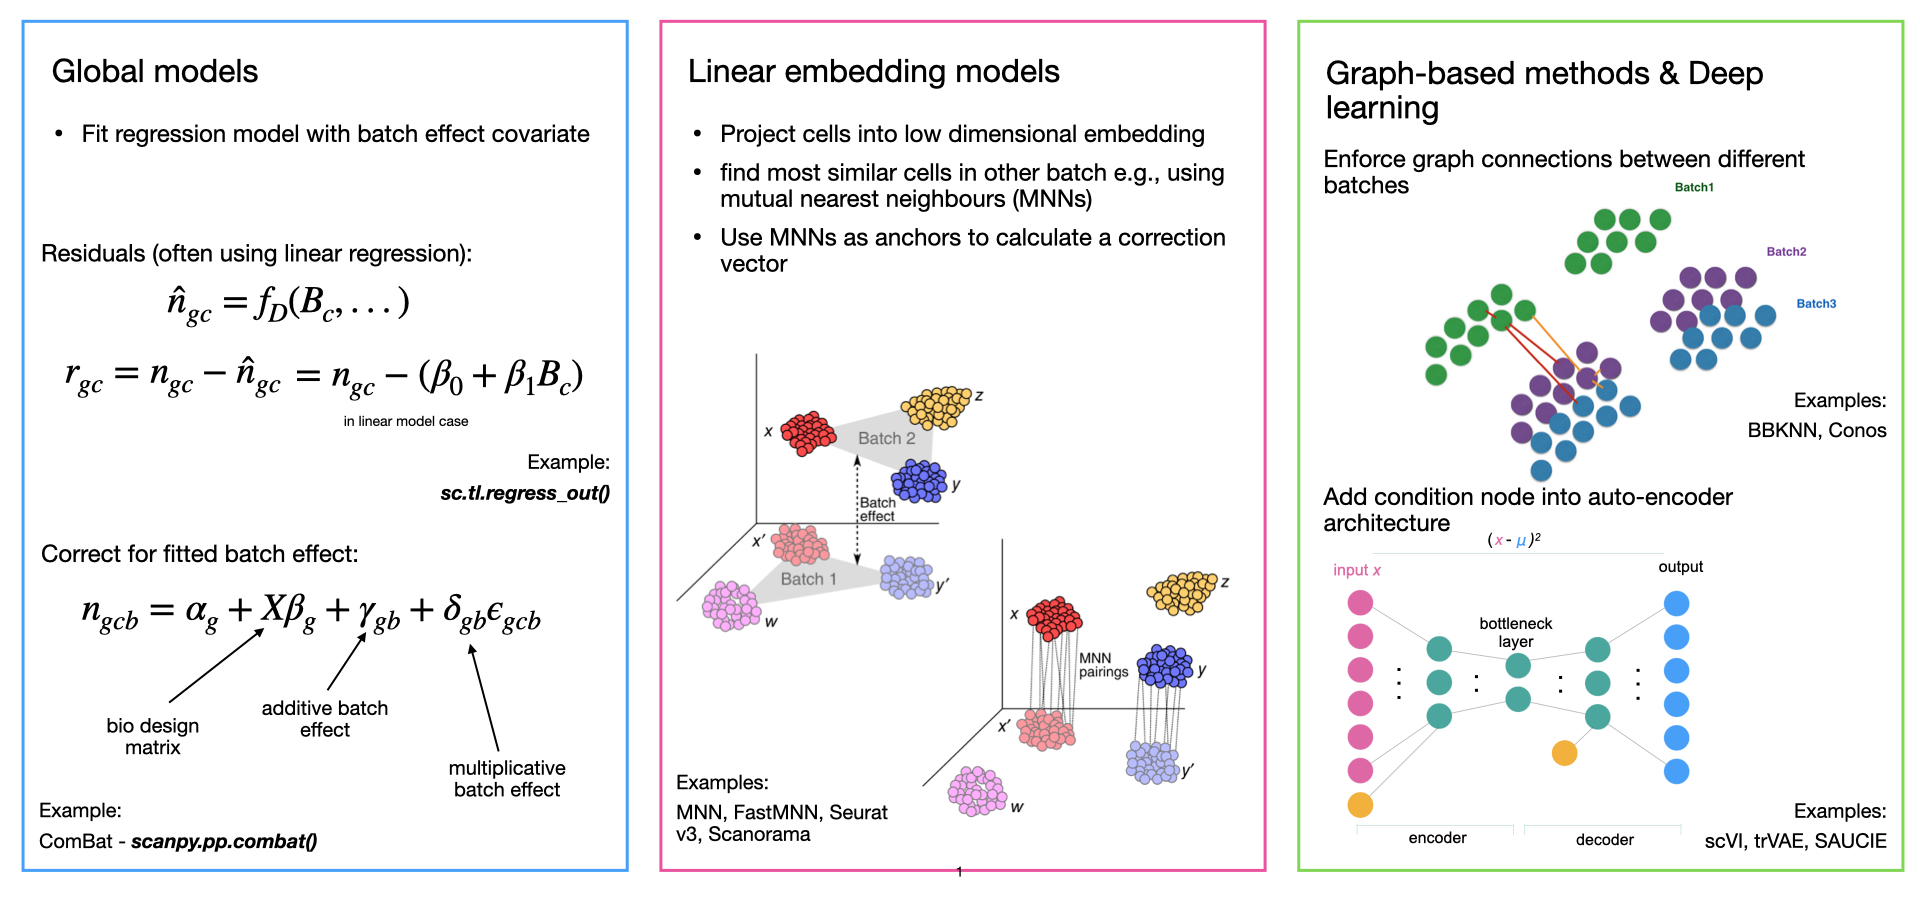




* **Global models** originate from bulk transcriptomics and model the batch effect as a consistent (additive and/or multiplicative) effect across all cells. A common example is ComBat [Johnson et al., 2007].

* **Linear embedding models** were the first single-cell-specific batch removal methods. These approaches often use a variant of singular value decomposition (SVD) to embed the data, then look for local neighborhoods of similar cells across batches in the embedding, which they use to correct the batch effect in a locally adaptive (non-linear) manner.  This is most common group of methods and prominent examples include the pioneering mutual nearest neighbors (MNN) method [Haghverdi et al., 2018] (which does not perform any dimensionality reduction), Seurat integration [Butler et al., 2018, Stuart et al., 2019], Scanorama [Hie et al., 2019], FastMNN [Haghverdi et al., 2018], and **<span style="color:red">Harmony</span>**   [Korsunsky et al., 2019].

* **Graph-based** methods are typically the fastest methods to run. These approaches use a nearest-neighbor graph to represent the data from each batch. Batch effects are corrected by forcing connections between cells from different batches and then allowing for differences in cell type compositions by pruning the forced edges. The most prominent example of these approaches is the Batch-Balanced k-Nearest Neighbor (BBKNN) method [Polański et al., 2019].

* **Deep learning** (DL) approaches are the most recent, and most complex methods for batch effect removal that typically require the most data for good performance. Most deep learning integration methods are based on autoencoder networks, and either condition the dimensionality reduction on the batch covariate in a conditional variational autoencoder (CVAE) or fit a locally linear correction in the embedded space. Prominent examples of DL methods are scVI [Lopez et al., 2018], scANVI [Xu et al., 2021], and scGen [Lotfollahi et al., 2019].

Some methods can use cell identity labels to provide the method with a reference for what biological variation should not be removed as a batch effect. As batch-effect removal is typically a preprocessing task, such approaches may not be applicable to many integration scenarios as labels are generally not yet available at this stage.

The removal of batch effects in scRNA-seq data has previously been divided into two subtasks: *batch correction* and *data integration* [Luecken and Theis, 2019]. These subtasks differ in the complexity of the batch effect that must be removed. Batch correction methods deal with batch effects between samples in the same experiment where cell identity compositions are consistent, and the effect is often quasi-linear. In contrast, data integration methods deal with complex, often nested, batch effects between datasets that may be generated with different protocols and where cell identities may not be shared across batches. While we use this distinction here we should not that these terms are often used interchangeably in general use. Given the differences in complexity, it is not surprising that different methods have been benchmarked as being optimal for these two subtasks.





## Comparison of data integration methods

When removing batch effects, **methods may overcorrect and remove meaningful biological variation in addition to the batch effect**. For this reason, it is important that integration performance is evaluated by considering both batch effect removal and the conservation of biological variation.

The k-nearest-neighbor Batch-Effect Test (kBET) was the first metric for quantifying batch correction of scRNA-seq data [Büttner et al., 2019]. Using kBET, the authors found that ComBat outperformed other approaches for batch correction while comparing predominantly global models. Building on this, two recent benchmarks [Tran et al., 2020] and [Chazarra-Gil et al., 2021] also benchmarked linear-embedding and deep-learning models on batch correction tasks with few batches or low biological complexity. These studies found that the linear-embedding models Seurat [Butler et al., 2018, Stuart et al., 2019] and Harmony [Korsunsky et al., 2019] performed well for simple batch correction tasks.

Benchmarking complex integration tasks poses additional challenges due to both the size and number of datasets as well as the diversity of scenarios. Recently, a large study used 14 metrics to benchmark 16 methods across integration method classes on five RNA tasks and two simulations [Luecken et al., 2021]. While top-performing methods per task differed, approaches that use cell type labels performed better across tasks. Furthermore, deep learning approaches scANVI (with labels), scVI, and scGen (with labels), as well as the linear embedding model Scanorama, performed best, particularly on complex tasks, <span style="color:red">while Harmony performed well on less complex tasks</span>. A similar benchmark performed for the specific purpose of integrating retina datasets to build an ocular mega-atlas also found that scVI outperformed other methods [Swamy et al., 2021].

While integration methods have now been extensively benchmarked, an optimal method for all scenarios does not exist. **Packages of integration performance metrics and evaluation pipelines like scIB and batchbench can be used to evaluate integration performance on your own data. However many metrics (particularly those that measure the conservation of biological variation) require ground-truth cell identity labels**.

<span style="color:green">yet in general, one can say that Harmony and Seurat consistently perform well for simple batch correction tasks, and scVI, scGen, scANVI, and Scanorama perform well for more complex data integration tasks.</span> . Extensive guidelines for data integration method choice can be found in [Luecken et al., 2021].



In [6]:
# Python packages
import scanpy as sc
import scvi
import bbknn
import scib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/lightning_fabric/__init__.py:29: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('lightning_fabric')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  __import__("pkg_resources").declare_namespace(__name__)
/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/pytorch_lightning/__init__.py:45: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('pytorch_lightning')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  __import__("pkg_resources").declare_namespace(__name__)
Global seed set to 0
/Users/nicolebussola/anaconda3/envs/LBP/lib/pytho

In [7]:


# R interface
from rpy2.robjects import pandas2ri
from rpy2.robjects import r
import rpy2.rinterface_lib.callbacks
import anndata2ri

pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/rpy2/robjects/pandas2ri.py:368: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  warnings.warn('The global conversion available with activate() '
/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/rpy2/robjects/numpy2ri.py:241: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  warnings.warn('The global conversion available with activate() '


In [8]:
%%R
# R packages
#install.packages("Seurat")
library(Seurat)


Errore in library(Seurat) : non c'è alcun pacchetto chiamato ‘Seurat’
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/rpy2/ipython/rmagic.py", line 385, in eval
    value, visible = ro.r("withVisible({%s\n})" % code)
  File "/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/rpy2/robjects/__init__.py", line 459, in __call__
    res = self.eval(p)
  File "/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/rpy2/robjects/functions.py", line 208, in __call__
    return (super(SignatureTranslatedFunction, self)
  File "/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/rpy2/robjects/functions.py", line 131, in __call__
    res = super(Function, self).__call__(*new_args, **new_kwargs)
  File "/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/rpy2/rinterface_lib/conversion.py", line 45, in _
    cdata = function(*args, **kwargs)
  File "/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/rpy2/rinterface.py", line 81

In [12]:
adata_raw = sc.read_h5ad(
    "GSE194122_openproblems_neurips2021_multiome_BMMC_processed.h5ad"
)
adata_raw.layers["logcounts"] = adata_raw.X
adata_raw

/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/anndata/_io/specs/registry.py:235: OldFormatWarning: Element '/layers' was written without encoding metadata.
  return self.callback(read_func, elem.name, elem, iospec=get_spec(elem))
/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/anndata/_io/utils.py:202: OldFormatWarning: Element '/obs/GEX_pct_counts_mt' was written without encoding metadata.
  return func(*args, **kwargs)
/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/anndata/_io/utils.py:202: OldFormatWarning: Element '/obs/GEX_n_counts' was written without encoding metadata.
  return func(*args, **kwargs)
/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/anndata/_io/utils.py:202: OldFormatWarning: Element '/obs/GEX_n_genes' was written without encoding metadata.
  return func(*args, **kwargs)
/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/anndata/_io/utils.py:202: OldFormatWarning: El

AnnData object with n_obs × n_vars = 69249 × 129921
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker'
    var: 'feature_types', 'gene_id'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts', 'logcounts'

The full dataset contains 69,249 cells and measurements for 129,921 features. There are two versions of the expression matrix, counts which contains the raw count values and logcounts which contains normalised log counts (these values are also stored in adata.X).

adata_raw
The obs slot contains several variables, some of which were calculated during pre-processing (for quality control) and others that contain metadata about the samples. The ones we are interested in here are:

<span style="color:purple">cell_type</span> - The annotated label for each cell

<span style="color:purple">batch</span> - The sequencing batch for each cell

In [13]:
# We define variables to hold these names so that it is clear how we are using them
# in the code. This also helps with reproducibility because if we decided to change
#one of them for whatever reason we can be sure it has changed in the whole notebook.
label_key = "cell_type"
batch_key = "batch"


In [14]:
adata_raw.obs[batch_key].value_counts()

batch
s4d8     9876
s4d1     8023
s3d10    6781
s1d2     6740
s1d1     6224
s2d4     6111
s2d5     4895
s3d3     4325
s4d9     4325
s1d3     4279
s2d1     4220
s3d7     1771
s3d6     1679
Name: count, dtype: int64

In [15]:
keep_batches = ["s3d3","s1d3", "s2d1", "s3d7"]
adata = adata_raw[adata_raw.obs[batch_key].isin(keep_batches)].copy()
adata

AnnData object with n_obs × n_vars = 14595 × 129921
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker'
    var: 'feature_types', 'gene_id'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts', 'logcounts'

In [16]:
adata.var["feature_types"].value_counts() #The type of each feature (RNA ie GE, or ATAC)

feature_types
ATAC    116490
GEX      13431
Name: count, dtype: int64

We can see that there are over 100,000 ATAC features but only around 13,000 gene expression (“GEX”) features. Integration of multiple modalities is a complex problem that will be described in the multimodal integration chapter, so for now we will subset to only the gene expression features. We also perform simple filtering to make sure we have no features with zero counts (this is necessary because by selecting a subset of samples we may have removed all the cells which expressed a particular feature).


In [17]:
adata = adata[:, adata.var["feature_types"] == "GEX"].copy()
sc.pp.filter_genes(adata, min_cells=1)
adata

AnnData object with n_obs × n_vars = 14595 × 13431
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker'
    var: 'feature_types', 'gene_id', 'n_cells'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts', 'logcounts'

**Because of the subsetting we also need to re-normalise the data.** Here we just normalise using global scaling by the total counts per cell.



In [18]:
adata.X = adata.layers["counts"].copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata.layers["logcounts"] = adata.X.copy()

Integrating samples from UMI and full-length protocols can present additional challenges. This is because full-length protocols are affected by gene-length bias (longer genes will be more highly expressed) while UMI data is not [Phipson et al., 2017]. Because of this, it is generally recommended to transform counts for full-length samples into a unit that corrects for gene-length (such as transcripts per million (TPM) [Wagner et al., 2012]) before attempting integration. This isn’t necessary however if all the samples being integrated used a full-length protocol.

It is always recommended to look at the raw data before performing any integration. This can give some indication of how big any batch effects are and what might be causing them (and therefore which variables to consider as the batch label). For some experiments, it might even suggest that integration is not required if samples already overlap. This is not uncommon for mouse or cell line studies from a single lab for example, where most of the variables which contribute to batch effects can be controlled (i.e. the batch correction setting).

In [19]:
# Perform HVG selection
sc.pp.highly_variable_genes(adata)
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
adata

AnnData object with n_obs × n_vars = 14595 × 13431
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker'
    var: 'feature_types', 'gene_id', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism', 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'distances', 'connectivities'

/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:163: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy(get_cmap(cmap))
/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/Users/nicolebussola/anaconda3/envs/LBP/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


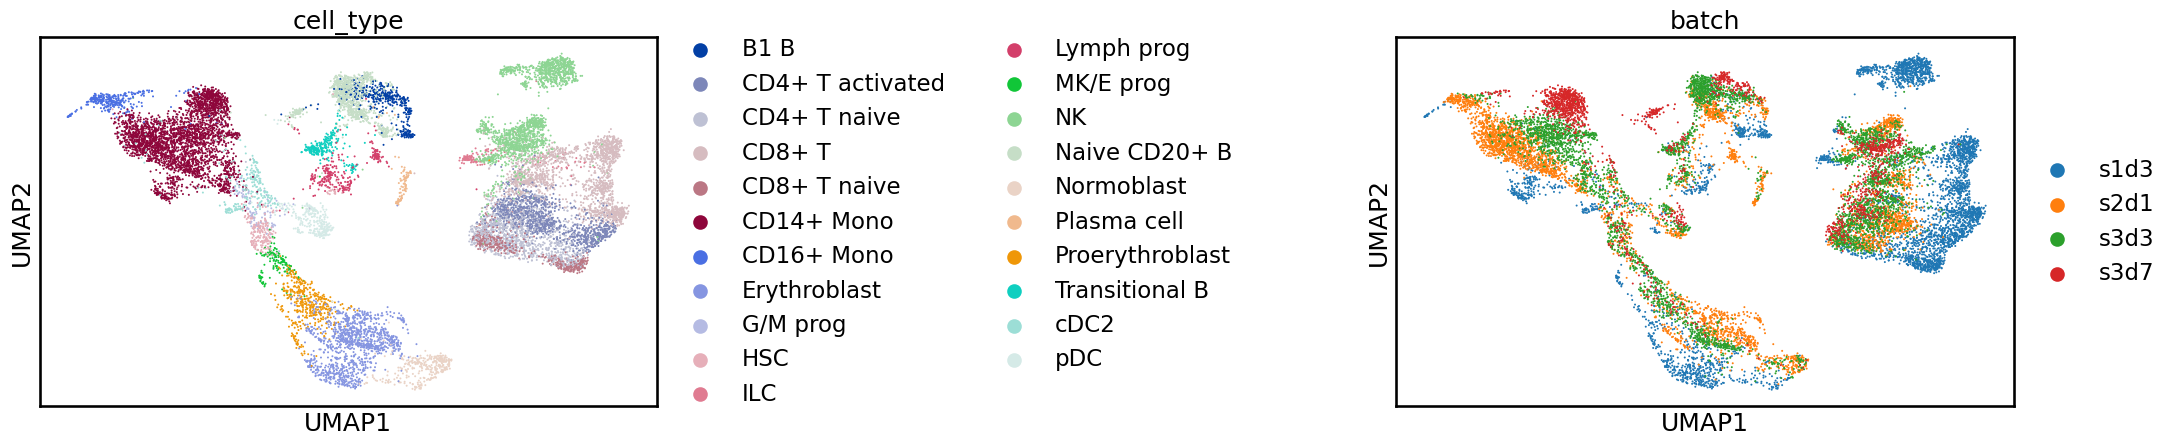

In [20]:
adata.uns[batch_key + "_colors"] = [
    "#1b9e77",
    "#d95f02",
    "#7570b3",
]  # Set custom colours for batches
sc.pl.umap(adata, color=[label_key, batch_key], wspace=1)

Now that we have confirmed there are batch effects to correct we can move on to the different integration methods. If the batches perfectly overlaid each other or we could discover meaningful cell clusters without correction then there would be no need to perform integration

## Batch-aware feature selection

We can perform batch-aware highly variable gene selection by setting the batch_key argument in the scanpy highly_variable_genes() function. **scanpy will then calculate HVGs for each batch separately and combine the results by selecting those genes that are highly variable in the highest number of batches**. We use the scanpy function here because it has this batch awareness built in. For other methods, we would have to run them on each batch individually and then manually combine the results.

In [21]:
sc.pp.highly_variable_genes(
    adata, n_top_genes=2000, flavor="cell_ranger", batch_key=batch_key
)
adata
adata.var

,feature_types,gene_id,n_cells,highly_variable,means,dispersions,dispersions_norm,highly_variable_nbatches,highly_variable_intersection
AL627309.5,GEX,ENSG00000241860,156,False,0.006473,0.756675,0.248791,1,False
LINC01409,GEX,ENSG00000237491,572,False,0.023217,0.717215,-0.087508,0,False
LINC01128,GEX,ENSG00000228794,684,False,0.026133,0.712341,-0.223809,0,False
NOC2L,GEX,ENSG00000188976,896,False,0.034168,0.683951,-0.823594,0,False
KLHL17,GEX,ENSG00000187961,112,False,0.004686,0.721254,0.005705,0,False
...,...,...,...,...,...,...,...,...,...
MT-ND5,GEX,ENSG00000198786,4236,False,0.196762,0.680975,-0.129177,0,False
MT-ND6,GEX,ENSG00000198695,1154,False,0.037876,0.683440,-0.411851,0,False
MT-CYB,GEX,ENSG00000198727,5823,False,0.375854,0.658054,-0.170571,0,False
AL592183.1,GEX,ENSG00000273748,823,False,0.037490,0.777422,0.749345,1,False


We can see there are now some additional columns in var:

* `highly_variable_nbatches` - The number of batches where each gene was found to be highly variable

* `highly_variable_intersection` - Whether each gene was highly variable in every batch

* `highly_variable` - Whether each gene was selected as highly variable after combining the results from each batch

highly_variable_nbatches
0    9553
1    1810
2     766
4     752
3     550
Name: count, dtype: int64

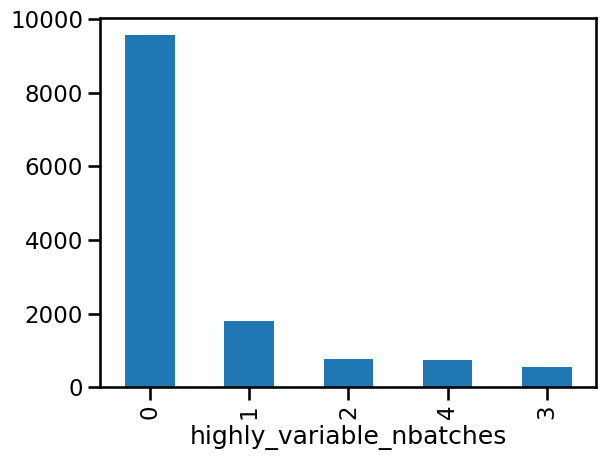

In [22]:
n_batches = adata.var["highly_variable_nbatches"].value_counts()
ax = n_batches.plot(kind="bar")
n_batches

we recommend selecting slightly too many genes rather than selecting too few and risk removing genes that are important for a rare cell type or a pathway of interest.

In [23]:
adata_hvg = adata[:, adata.var["highly_variable"]].copy()
adata_hvg

AnnData object with n_obs × n_vars = 14595 × 2000
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker'
    var: 'feature_types', 'gene_id', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'batch_colors', 'cell_type_colors'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'co

## VAE integration

The conditional part refers to conditioning this dimensionality reduction process on a particular covariate (in this case batches) such that the covariate does not affect the low-dimensional representation. In benchmarking studies scVI has been shown to perform well across a range of datasets with a good balance of batch correction while conserving biological variability [Luecken et al., 2021]. scVI models raw counts directly, so it is important that we provide it with a count matrix rather than a normalized expression matrix.

In [24]:
import scvi

In [25]:
adata_scvi = adata_hvg.copy() # copy as we will try more methods

# Data preparation
scvi.model.SCVI.setup_anndata(adata_scvi, layer="counts", batch_key=batch_key)

adata_scvi

AnnData object with n_obs × n_vars = 14595 × 2000
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', '_scvi_batch', '_scvi_labels'
    var: 'feature_types', 'gene_id', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'batch_colors', 'cell_type_colors', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pc

NameError: name 'adata' is not defined